In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV

In [2]:
df_combined = pd.read_parquet("data/df_combined.parquet")

In [3]:
train_mask = df_combined.split == 'train'
val_mask = df_combined.split == 'val'
assert set(df_combined.loc[train_mask, 'Place_ID']) & set(df_combined.loc[val_mask, 'Place_ID']) == set()

X_train = df_combined.loc[train_mask].drop(columns=['target','split', 'Place_ID', 'Date'])
y_train = df_combined.loc[train_mask, 'target']
X_val   = df_combined.loc[val_mask].drop(columns=['target','split', 'Place_ID', 'Date'])
y_val   = df_combined.loc[val_mask, 'target']

## Baseline Model - Dummy Model

In [4]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(np.zeros((len(y_train), 1)), y_train)  # Features irrelevant, Dummy ignoriert X komplett
y_pred = dummy.predict(np.zeros((len(y_val), 1)))

baseline_rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 42.12


## Fit model

In [5]:
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
# Make predictions on test set
pred =model.predict(X_val)

In [7]:
xgboost_rmse = mean_squared_error(y_val, pred, squared=False)
print(f"xgboost RMSE: {xgboost_rmse:.2f}")

xgboost RMSE: 31.85


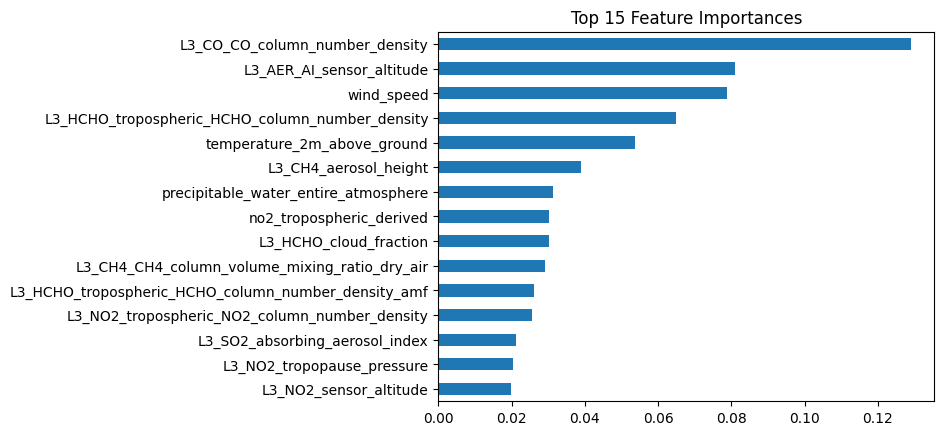

In [9]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.show()

In [ ]:
drop_metadata = ['L3_AER_AI_sensor_altitude', 'L3_NO2_sensor_altitude', 'L3_CO_sensor_altitude']
df_combined = df_combined.drop(columns=drop_metadata)

## Advanced Data Split with GroupKFold

In [97]:
gkf = GroupKFold(n_splits=5)
fold_scores = []

for train_idx, val_idx in gkf.split(df_combined, groups=df_combined['Place_ID']):
    X_tr = df_combined.iloc[train_idx].drop(columns=['target','split', 'Place_ID', 'Date'])
    y_tr = df_combined.iloc[train_idx]['target']
    X_va = df_combined.iloc[val_idx].drop(columns=['target','split', 'Place_ID', 'Date'])
    y_va = df_combined.iloc[val_idx]['target']

    model = XGBRegressor(random_state=42)
    model.fit(X_tr, y_tr)
    rmse = mean_squared_error(y_va, model.predict(X_va), squared=False)
    fold_scores.append(rmse)
    print(f"Fold RMSE: {rmse:.3f}")

print(f"\nMean RMSE: {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

Fold RMSE: 37.047
Fold RMSE: 34.170
Fold RMSE: 31.460
Fold RMSE: 39.357
Fold RMSE: 32.302

Mean RMSE: 34.867 ± 2.952


In [102]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from scipy.stats import randint, uniform

param_dist = {
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),
    'n_estimators': randint(100, 800),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),   # Regularisierung gegen Overfitting auf kleine Location-Gruppen
    'reg_lambda': uniform(0.5, 4.5),      # L2-Regularisierung, hilfreich bei vielen korrelierten Satellite-Features
}

X_full = df_combined.drop(columns=['target','split','Place_ID', 'Date'])
y_full = df_combined['target']
groups_full = df_combined['Place_ID']

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=100,  # statt 25
    cv=GroupKFold(n_splits=5),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

random_search.fit(X_full, y_full, groups=groups_full)
print(f"Best params: {random_search.best_params_}")
print(f"Best RMSE: {-random_search.best_score_:.3f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'colsample_bytree': 0.7390476857930735, 'learning_rate': 0.019223357630697886, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 744, 'reg_lambda': 2.573504456147266, 'subsample': 0.682533487362317}
Best RMSE: 33.038


Best params: {
'colsample_bytree': 0.7390476857930735,

'learning_rate': 0.019223357630697886, 

'max_depth': 8, 

'min_child_weight': 1, 

'n_estimators': 744, 

'reg_lambda': 2.573504456147266, 

'subsample': 0.682533487362317}

Best RMSE: 33.038